<a href="https://colab.research.google.com/github/KuChoiLab/2026_bomun_workshop/blob/main/Proteomics_practice/SomaScan/SomaScan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Young group

Male:
02 (age 26), 05 (20), 16 (25), 18 (19), 19 (19), 20 (19), 43 (25), 45 (30), 48 (30), 49 (28), 57 (29), 58 (26), 61 (22), 72 (27)

Female:
01 (27), 03 (27), 04 (26), 06 (22), 07 (25), 08 (33), 09 (24), 10 (33), 11 (27), 12 (34), 13 (24), 14 (32), 15 (28), 17 (22), 41 (27), 42 (23), 50 (30), 52 (34), 62 (32), 63 (26), 65 (25), 66 (24), 68 (27), 69 (25), 75 (31), 76 (27)

Old group

Male:
22 (72), 24 (78), 25 (66), 26 (66), 27 (66), 29 (66), 31 (65), 32 (73), 38 (71), 40 (72), 44 (66), 47 (68), 70 (74), 77 (72)

Female:
21 (70), 23 (71), 28 (66), 30 (79), 33 (71), 34 (69), 35 (71), 36 (68), 37 (73), 39 (65), 46 (72), 51 (65), 53 (67), 54 (69), 55 (67), 56 (65), 59 (65), 60 (75), 64 (69), 67 (70), 71 (71), 73 (66), 74 (73), 78 (70), 79 (70), 80 (69)

Summary (Age)

Young group age range: 19–34
Old group age range: 65–79

In [ ]:
# Download tools to use R in a Python runtime
# As shown in the bottom right, the current environment is python3

!pip install -q rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
# Download and extract the R library packages

!pip install -q gdown

import gdown

gdown.download(
    id="1Nxs1yX3LfgjtYSYdZ1lAxulGHzoPsGW5",
    output="SomaScan_library_packages.tar",
    quiet=False
)

!tar -xf SomaScan_library_packages.tar -C /content/

Downloading...
From (original): https://drive.google.com/uc?id=1Nxs1yX3LfgjtYSYdZ1lAxulGHzoPsGW5
From (redirected): https://drive.google.com/uc?id=1Nxs1yX3LfgjtYSYdZ1lAxulGHzoPsGW5&confirm=t&uuid=8a0b732d-ea84-4f7d-8031-bf21df672e59
To: /content/SomaScan_library_packages.tar
100%|██████████| 878M/878M [00:10<00:00, 85.9MB/s]


In [ ]:
# Set the R package library path and load the packages

%%R

lib <- "/content/content/drive/MyDrive/MOFA_test/R_libs"
.libPaths(c(lib, .libPaths()))

pkgs <- c(
"SomaDataIO","limma","clusterProfiler","org.Hs.eg.db","dplyr",
"ggplot2","tibble","ggrepel","pheatmap","openxlsx"
)

for(p in pkgs){
  suppressPackageStartupMessages(library(p, character.only = TRUE))
}

In [ ]:
# Download the raw intensity matrix

!pip install -q gdown

import gdown

file_id = "1JLRZizVgSFuhfHRm4K9H6B5iB24P4LFO"
output = "SomaScan_raw_intensity_matrix.adat"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1JLRZizVgSFuhfHRm4K9H6B5iB24P4LFO
To: /content/SomaScan_raw_intensity_matrix.adat
100%|██████████| 10.1M/10.1M [00:00<00:00, 150MB/s]


'SomaScan_raw_intensity_matrix.adat'

In [ ]:
# Download the metadata of the samples

!pip install -q gdown

import gdown

file_id = "1-cTPrVun8RzGNswYcFOPv3ZprddK-Uz4"
output = "SomaScan_metadata.txt"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1-cTPrVun8RzGNswYcFOPv3ZprddK-Uz4
To: /content/SomaScan_metadata.txt
100%|██████████| 2.03k/2.03k [00:00<00:00, 4.00MB/s]


'SomaScan_metadata.txt'

In [ ]:
# Load raw intensity matrix

# "Warning message: No SlideId_Subarray found in ADAT."
# This is common in SomaScan data and does not affect downstream analyses

%%R

adat <- read_adat("SomaScan_raw_intensity_matrix.adat")

stopifnot(is.soma_adat(adat))
stopifnot(is_intact_attr(adat))
getSomaScanVersion(adat)

adat <- SomaDataIO::col2rn(adat, "SampleID")

In addition: Warning messages:
1: No SlideId_Subarray found in ADAT. Rows numbered sequentially. 
2: `adat` already has row names. They will be over-written. 


In [ ]:
# Retain plasma samples that passed in normalization stage of preprocessing
# Ensures only high-quality biological samples are used for downstream analysis

%%R

adat_qc <- adat %>%
  dplyr::filter(
    SampleType == "Plasma",
    RowCheck_PassFlag == "PASS"
  )

In [ ]:
# Remove controls and extract analytes

%%R

analytes_all <- getAnalytes(adat_qc, rm.controls = FALSE)
analytes_no_control <- getAnalytes(adat_qc, rm.controls = TRUE)
feat <- getAnalyteInfo(adat_qc)

In [ ]:
# Remove non-human SeqId and standardize sequence naming

%%R

nonhuman_seqid_raw <- feat %>%
  dplyr::filter(!is.na(Organism)) %>%
  dplyr::filter(Organism != "Human") %>%
  dplyr::pull(SeqId) %>%
  unique()

nonhuman_seqid_fixed <- gsub("-", ".", nonhuman_seqid_raw)
nonhuman_seq <- paste0("seq.", nonhuman_seqid_fixed)

In [ ]:
# Prepare expression matrix
# Remove non-human analytes, detect outliers, apply log2 transform, and extract expression matrix
# total : 11012   control : 59   non-human : 496   filtered : 10457

%%R

analytes <- setdiff(analytes_no_control, nonhuman_seq)

n_initial_analytes <- length(analytes_all)
n_removed_control <- length(analytes_all) - length(analytes_no_control)
n_removed_nonhuman <- length(analytes_no_control) - length(analytes)
n_final_analytes <- length(analytes)

print(n_initial_analytes)
print(n_removed_control)
print(n_removed_nonhuman)
print(n_final_analytes)

[1] 11012
[1] 59
[1] 496
[1] 10457


→ No observations were flagged at this flagging proportion: 0.05


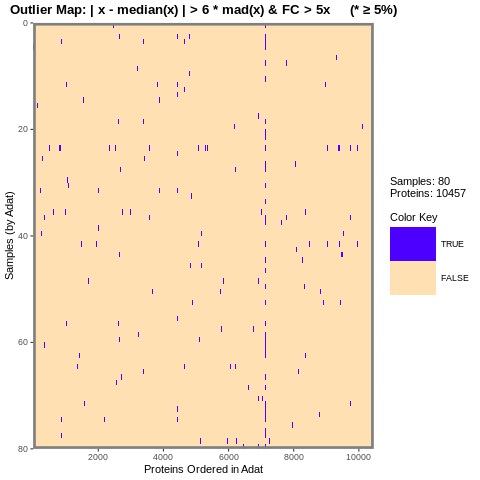

In [ ]:
# Detect and visualize sample outliers
# Identify MAD-based outliers across analytes
# MAD(median absolute deviation) = median(|x − median(x)|)

%%R

outlier_map <- calcOutlierMap(adat_qc[, analytes])

plot(
  outlier_map,
  flags = 0.05,
  main = "MAD-based Outlier Map",
  x.lab = "Analytes",
  y.lab = "Samples"
)

In [ ]:
# Log2 transform analyte signals and extract expression matrix
# Prepare analysis-ready expression data

%%R

adat_qc_log2 <- adat_qc

expr_mat <- adat_qc %>%
  dplyr::select(all_of(analytes)) %>%
  as.matrix()

In [ ]:
# Log2 transform expression matrix
# Stabilize signal distribution for downstream analysis

%%R

expr_log <- log2(expr_mat + 1)

In [ ]:
# Load and align sample metadata
# Match external metadata with ADAT samples and construct analysis metadata table

%%R

sample_info <- read.delim(
  file = "SomaScan_metadata.txt",
  sep = "\t",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

sample_info <- sample_info %>%
  dplyr::rename(
    LabID = `Lab#`,
    SampleID = `Sample ID`
  )

meta_cols <- getMeta(adat_qc)
adat_meta <- adat_qc %>% dplyr::select(all_of(meta_cols))

adat_ids <- rownames(adat_qc)
sample_info2 <- sample_info %>%
  dplyr::filter(LabID %in% adat_ids) %>%
  dplyr::mutate(LabID = factor(LabID, levels = adat_ids)) %>%
  dplyr::arrange(LabID) %>%
  tibble::column_to_rownames("LabID")

meta_all <- dplyr::bind_cols(sample_info2, adat_meta)

meta <- meta_all %>%
  dplyr::select(Group, Sex, Age, PlateId, BatchID) %>%
  dplyr::mutate(
    Group = factor(Group, levels = c("Young", "Old")),
    Sex   = factor(Sex)
  )

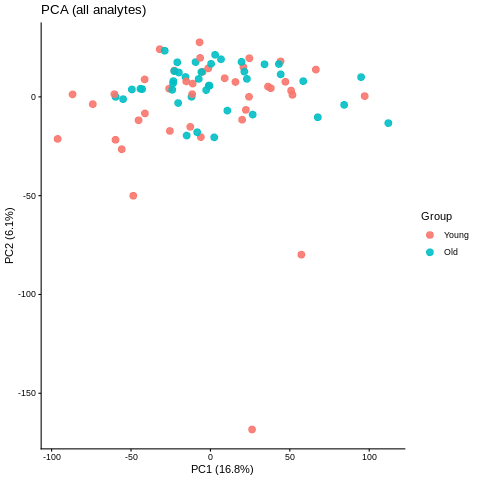

In [ ]:
# Run PCA on log-transformed expression matrix with centering and scaling
# Merge PCA scores with sample metadata for visualization and interpretation
# Plot PC1 vs PC2 to assess global structure, group separation, and batch effects

%%R

pca_obj_all <- prcomp(expr_log,
                      center = TRUE,
                      scale. = TRUE)

pca_df_all <- as.data.frame(pca_obj_all$x) %>%
  tibble::rownames_to_column("LabID") %>%
  dplyr::left_join(meta %>% tibble::rownames_to_column("LabID"), by = "LabID")

ve_all <- (pca_obj_all$sdev^2) / sum(pca_obj_all$sdev^2)

p_pca_all <- ggplot(pca_df_all, aes(PC1, PC2, color = Group)) +
  geom_point(size = 3, alpha = 0.9) +
  theme_classic() +
  labs(
    title = "PCA (all analytes)",
    x = paste0("PC1 (", round(100 * ve_all[1], 1), "%)"),
    y = paste0("PC2 (", round(100 * ve_all[2], 1), "%)")
  )

print(p_pca_all)

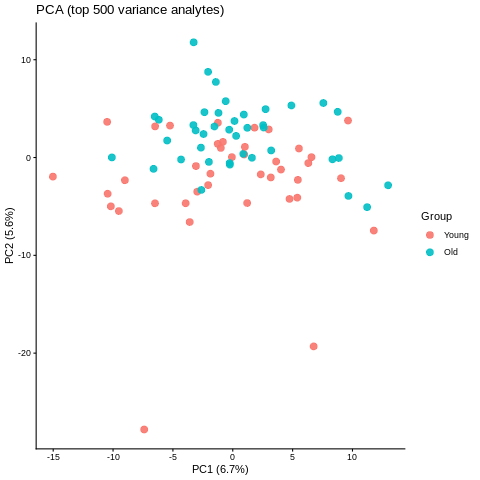

In [ ]:
# Select top 500 analytes with highest variance to capture dominant biological signal
# Perform PCA on variance-filtered expression matrix with centering and scaling
# Visualize PC1 vs PC2 to evaluate structure, group separation, and technical effects

%%R

vars <- apply(expr_log, 2, var, na.rm = TRUE)
top500_ids <- names(sort(vars, decreasing = TRUE))[1:500]

pca_obj <- prcomp(expr_log[, top500_ids, drop = FALSE],
                  center = TRUE, scale. = TRUE)

pca_df <- as.data.frame(pca_obj$x) %>%
  tibble::rownames_to_column("LabID") %>%
  dplyr::left_join(meta %>% tibble::rownames_to_column("LabID"), by = "LabID")

ve <- (pca_obj$sdev^2) / sum(pca_obj$sdev^2)

p_pca <- ggplot(pca_df, aes(PC1, PC2, color = Group)) +
  geom_point(size = 3, alpha = 0.9) +
  theme_classic() +
  labs(
    title = "PCA (top 500 variance analytes)",
    x = paste0("PC1 (", round(100 * ve[1], 1), "%)"),
    y = paste0("PC2 (", round(100 * ve[2], 1), "%)")
  )

print(p_pca)

In [ ]:
# Fit limma model and compute contrast
# Estimate differential expression between groups using empirical Bayes

%%R

design <- model.matrix(~ 0 + Group, data = meta)
colnames(design) <- gsub("^Group", "", colnames(design))

fit <- limma::lmFit(t(expr_log), design)
cont <- limma::makeContrasts(Old_vs_Young = Old - Young, levels = design)
fit2 <- limma::contrasts.fit(fit, cont)
fit2 <- limma::eBayes(fit2)

In [ ]:
# Extract differential expression results from limma model for Old vs Young comparison

%%R

res <- limma::topTable(
  fit2,
  coef = "Old_vs_Young",
  number = Inf,
  adjust.method = "BH"
) %>%
  tibble::rownames_to_column("Analyte")

In [ ]:
# Retrieve SomaScan analyte annotation and construct mapping table (ENTREZ ID, gene symbol, target label)

%%R

adat_anno <- suppressMessages(SomaDataIO::getAnalyteInfo(adat_qc))

anno_map <- adat_anno %>%
  dplyr::select(
    Analyte  = AptName,
    ENTREZID = `Entrez.Gene.ID`,
    SYMBOL   = `Entrez.Gene.Symbol`
  ) %>%
  dplyr::mutate(
    Target = dplyr::if_else(
      !is.na(SYMBOL) & SYMBOL != "",
      SYMBOL,
      ENTREZID
    )
  )

res <- res %>%
  dplyr::left_join(anno_map %>% dplyr::select(Analyte, Target), by = "Analyte")

In [ ]:
# Define differential analytes using FDR and logFC thresholds and compute −log10(FDR) for downstream visualization

%%R

FDR_CUTOFF <- 0.1
LFC_CUTOFF <- log2(1.5)

res2 <- res %>%
  dplyr::mutate(
    is_diff = (adj.P.Val <= FDR_CUTOFF) & (abs(logFC) > LFC_CUTOFF),
    neglog10FDR = -log10(pmax(adj.P.Val, .Machine$double.xmin))
  )

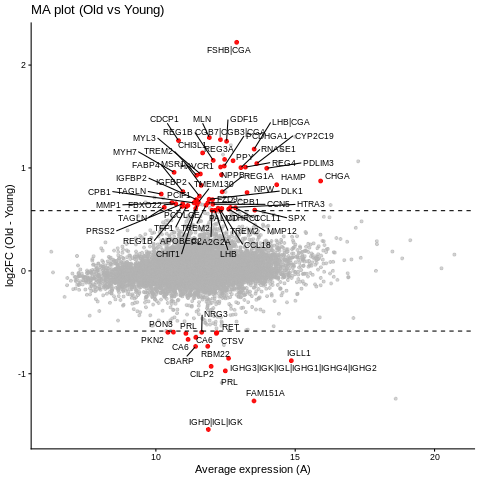

In [ ]:
# Generate MA plot for differential analytes
# Highlight significant features

%%R

group_colors <- c(Young = "red2", Old = "blue2")

p_ma <- ggplot(res2, aes(x = AveExpr, y = logFC)) +
  geom_point(color = "grey70", alpha = 0.6, size = 1.2) +
  geom_point(
    data = res2 %>% dplyr::filter(is_diff),
    aes(x = AveExpr, y = logFC),
    color = "red",
    alpha = 0.9,
    size = 1.6
  ) +
  ggrepel::geom_text_repel(
    data = res2 %>% dplyr::filter(is_diff),
    aes(label = Target),
    size = 3,
    max.overlaps = Inf
  ) +
  theme_classic() +
  labs(
    title = "MA plot (Old vs Young)",
    x = "Average expression (A)",
    y = "log2FC (Old - Young)"
  ) +
  geom_hline(yintercept = c(-LFC_CUTOFF, LFC_CUTOFF), linetype = "dashed")

print(p_ma)

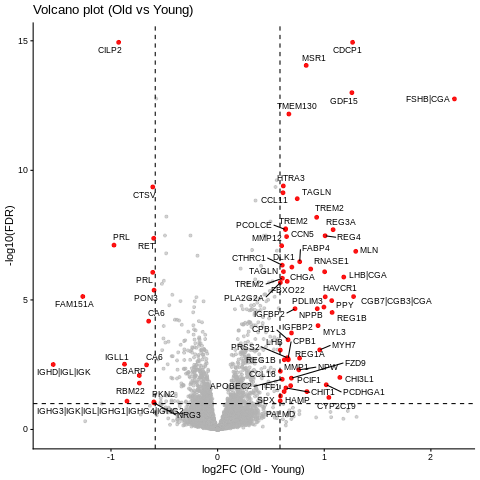

In [ ]:
# Generate volcano plot for differential analytes
# Highlight significant features

%%R

p_vol <- ggplot(res2, aes(x = logFC, y = neglog10FDR)) +
  geom_point(color = "grey70", alpha = 0.6, size = 1.2) +
  geom_point(
    data = res2 %>% dplyr::filter(is_diff),
    aes(x = logFC, y = neglog10FDR),
    color = "red",
    alpha = 0.9,
    size = 1.6
  ) +
  ggrepel::geom_text_repel(
    data = res2 %>% dplyr::filter(is_diff),
    aes(label = Target),
    size = 3,
    max.overlaps = Inf
  ) +
  theme_classic() +
  labs(
    title = "Volcano plot (Old vs Young)",
    x = "log2FC (Old - Young)",
    y = "-log10(FDR)"
  ) +
  geom_hline(yintercept = -log10(FDR_CUTOFF), linetype = "dashed") +
  geom_vline(xintercept = c(-LFC_CUTOFF, LFC_CUTOFF), linetype = "dashed")

print(p_vol)

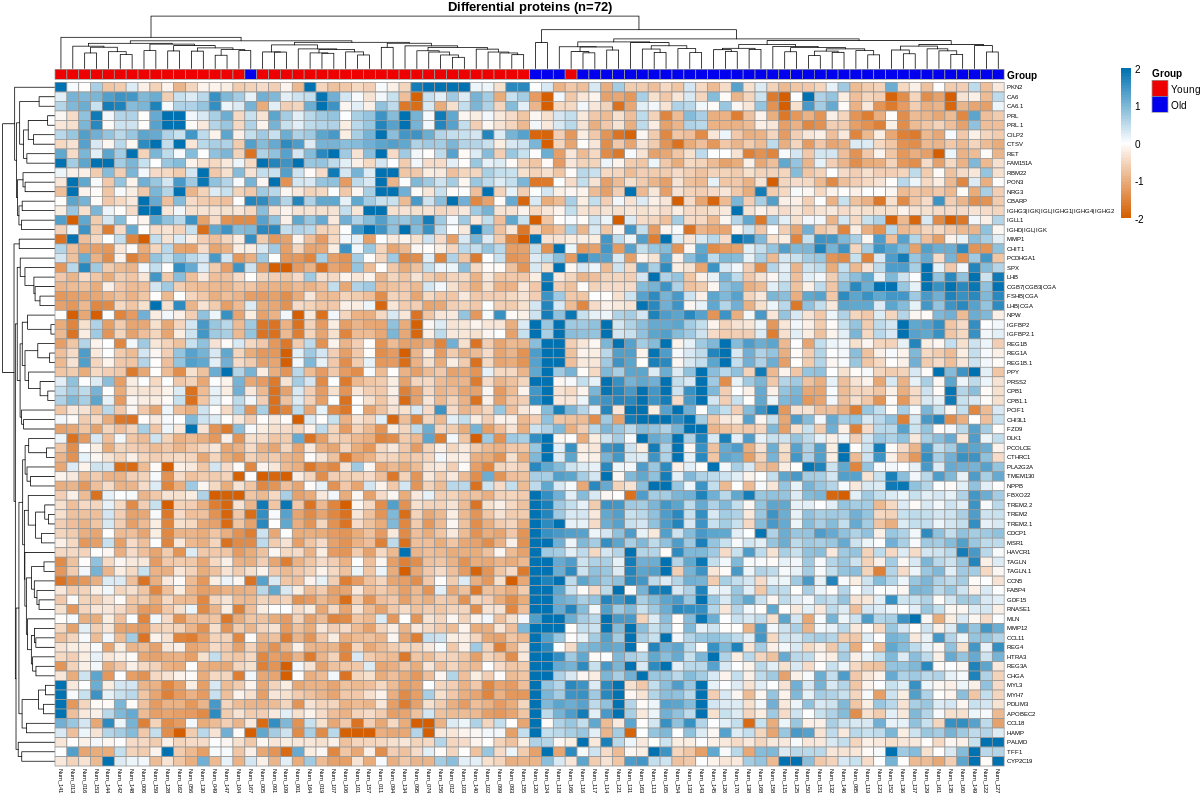

In [ ]:
# Generate heatmap of differential proteins
# Z-score scale expression and visualize group patterns

%%R -w 1200 -h 800

diff_ids <- intersect(
  res2 %>% dplyr::filter(is_diff) %>% dplyr::pull(Analyte),
  colnames(expr_log)
)

mat <- t(expr_log[rownames(meta), diff_ids, drop = FALSE])
mat_z <- t(scale(t(mat)))

target_vec <- anno_map$Target[match(rownames(mat_z), anno_map$Analyte)]
target_vec[is.na(target_vec) | target_vec == ""] <- rownames(mat_z)[is.na(target_vec) | target_vec == ""]
rownames(mat_z) <- make.unique(as.character(target_vec))

ann_col <- meta[colnames(mat_z), "Group", drop = FALSE]

breaks_z <- seq(-2, 2, length.out = 101)
colors_z <- colorRampPalette(c("#D55E00", "white", "#0072B2"))(100)

pheatmap::pheatmap(
  mat_z,
  annotation_col = ann_col,
  annotation_colors = list(Group = group_colors),
  breaks = breaks_z,
  color = colors_z,
  show_rownames = TRUE,
  fontsize_row = 6,
  fontsize_col = 6,
  main = paste0("Differential proteins (n=", nrow(mat_z), ")")
)

**Differential proteins**

Upregulated in Old (logFC > 0): GDF15, TREM2, MSR1, ...


Upregulated in Young (logFC < 0): PRL, CILP2, CTSV, ...

1. Tanaka, T. et al. Plasma proteomic signature of age in healthy humans. Nature Medicine 24, 833–841 (2018).
2. Colonna, M. & Wang, Y. TREM2 variants: new keys to decipher Alzheimer disease pathogenesis. Nature Reviews Neuroscience 17, 201–207 (2016).
3. Nielsen, M. C. et al. Macrophage scavenger receptor 1 and the role of lipid uptake in aging and age-related disease. Journal of Molecular Medicine 94, 1–12 (2016).
4. Roelfsema, F. & Veldhuis, J. D. Neuroendocrine control of prolactin secretion in aging humans. Endocrine Reviews 34, 673–691 (2013).
5. Södersten, F. et al. Cartilage intermediate layer proteins in tissue remodeling and age-related degeneration. Osteoarthritis and Cartilage 25, 109–117 (2017).
6. Turk, V., Stoka, V. & Turk, B. Lysosomal cathepsins: structure, function and their role in aging and neurodegeneration. Ageing Research Reviews 32, 22–37 (2016).

In [ ]:
# Map analytes to ENTREZ IDs and construct ranked gene list using t statistics (effect size + variance) for input of GSEA

%%R

gene_df <- res %>%
  dplyr::left_join(
    anno_map %>% dplyr::select(Analyte, ENTREZID),
    by = "Analyte"
  ) %>%
  dplyr::filter(!is.na(ENTREZID)) %>%
  dplyr::distinct(ENTREZID, .keep_all = TRUE)

gene_list <- gene_df$t
names(gene_list) <- gene_df$ENTREZID
gene_list <- sort(gene_list, decreasing = TRUE)

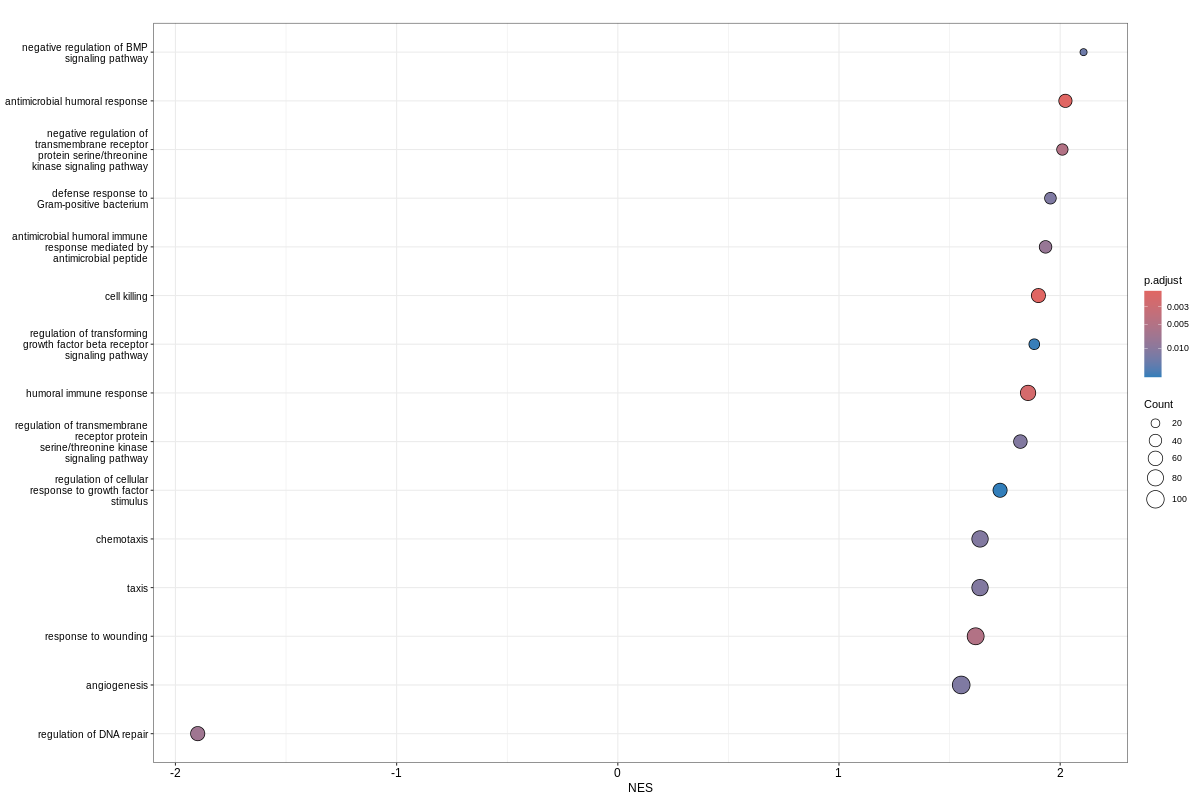

In [ ]:
# Run GSEA (GO Biological Process) using t statistic–based ranked gene list
# Convert results to data frame and visualize enriched pathways
# Takes about 1 minute

%%R -w 1200 -h 800

gsea_bp <- clusterProfiler::gseGO(
  geneList = gene_list,
  OrgDb = org.Hs.eg.db,
  ont = "BP",
  keyType = "ENTREZID",
  minGSSize = 10,
  maxGSSize = 500,
  pvalueCutoff = 0.05,
  verbose = FALSE
)

gsea_bp_res <- as.data.frame(gsea_bp)

p_gsea_bp <- clusterProfiler::dotplot(
  gsea_bp,
  showCategory = 15,
  x = "NES"
) +
theme(axis.text.y = element_text(size = 10))

print(p_gsea_bp)

**Significantly enriched GO BP terms**

Upregulated in Old (NES >0) : antimicrobial humoral immune response, humoral immune response, cell killing

Age-associated immune remodeling → chronic low-grade inflammation → increased antibody-mediated defense, antimicrobial effector production, and cytotoxic activity → accumulation of immune effector proteins in circulation

(Franceschi, C. et al. Inflammaging and ‘Garb-aging’. Trends in Endocrinology & Metabolism 28, 199–212 (2017).)


Upregulated in Young (NES <0) : regulation of DNA repair

Efficient genome maintenance → robust DNA damage sensing and repair pathway activity → preservation of genomic stability → delayed cellular senescence and healthier cellular function

(López-Otín, C. et al. The hallmarks of aging. Cell 153, 1194–1217 (2013).)